In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/shakespeares-sonnet-nlp/sonnets.txt


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.layers import Dense,Flatten,Embedding,Bidirectional,Conv1D,GlobalMaxPooling1D,Input,LSTM
from tensorflow.keras.optimizers import Adam,RMSprop
from tensorflow.keras.models import Model,Sequential

In [3]:
data=open('/kaggle/input/shakespeares-sonnet-nlp/sonnets.txt').read()
corpus=data.lower().split('\n')
print(len(corpus))

2159


In [4]:
vectorize_layer=tf.keras.layers.TextVectorization()
vectorize_layer.adapt(corpus)

I0000 00:00:1754206715.340896      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
vocabulary=vectorize_layer.get_vocabulary()
print(vocabulary)

['', '[UNK]', 'and', 'the', 'to', 'of', 'my', 'i', 'in', 'that', 'thy', 'thou', 'with', 'for', 'is', 'not', 'me', 'but', 'a', 'thee', 'love', 'so', 'be', 'as', 'all', 'you', 'which', 'his', 'when', 'this', 'it', 'by', 'your', 'doth', 'do', 'from', 'on', 'or', 'no', 'then', 'have', 'what', 'are', 'if', 'will', 'more', 'their', 'mine', 'shall', 'sweet', 'eyes', 'time', 'they', 'nor', 'beauty', 'her', 'art', 'yet', 'heart', 'o', 'than', 'now', 'can', 'thine', 'should', 'one', 'make', 'hath', 'fair', 'where', 'he', 'still', 'how', 'eye', 'true', 'him', 'see', 'loves', 'am', 'she', 'like', 'though', 'those', 'being', 'some', 'every', 'were', 'such', 'own', 'who', 'was', 'upon', 'myself', 'may', 'dost', 'say', 'praise', 'live', 'world', 'most', 'give', 'might', 'let', 'did', 'at', 'why', 'times', 'ill', 'day', 'since', 'even', 'truth', 'show', 'new', 'life', 'well', 'thus', 'old', 'night', 'look', 'best', 'would', 'thyself', 'must', 'dear', 'these', 'part', 'worth', 'whose', 'nothing', 'made

In [6]:
print(len(vocabulary))

3189


In [7]:
vocab_size=vectorize_layer.vocabulary_size()
print(vocab_size)

3189


In [8]:
vectorize_layer(corpus[10])

<tf.Tensor: shape=(7,), dtype=int64, numpy=array([ 211,   63,   88, 1294, 2979,   10, 1269])>

In [9]:
input_sequence=[]
for line in corpus:
    sequence=vectorize_layer(line).numpy()
    for i in range(1,len(sequence)):
        n_gram_sequence=sequence[:i+1]
        input_sequence.append(n_gram_sequence)


In [10]:
max_sequence_length=max([len(x) for x in input_sequence])
input_sequence=np.array(tf.keras.utils.pad_sequences(input_sequence,maxlen=max_sequence_length,padding='pre'))

In [11]:
len(input_sequence)

15355

In [12]:
print(input_sequence[0:6])

[[   0    0    0    0    0    0    0    0    0   35  489]
 [   0    0    0    0    0    0    0    0   35  489 1259]
 [   0    0    0    0    0    0    0   35  489 1259  164]
 [   0    0    0    0    0    0   35  489 1259  164  230]
 [   0    0    0    0    0   35  489 1259  164  230  582]
 [   0    0    0    0    0    0    0    0    0    9  935]]


In [13]:
xs,labels=input_sequence[:,:-1],input_sequence[:,-1]

In [14]:
ys=tf.keras.utils.to_categorical(labels)

In [15]:
ys[0:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [16]:
NUM_BATCHES=16
LSTM_UNITS=128
EMBEDDING_DIM=100

In [18]:
dataset=tf.data.Dataset.from_tensor_slices((xs,ys))
dataset=dataset.batch(NUM_BATCHES)
dataset=dataset.prefetch(tf.data.AUTOTUNE)

In [28]:
model=Sequential([
    Input(shape=(max_sequence_length,)),
    Embedding(vocab_size,EMBEDDING_DIM),
    Bidirectional(LSTM(LSTM_UNITS)),
    Dense(vocab_size,activation='softmax')
])

In [29]:
model.compile(optimizer=Adam(0.01),metrics=['accuracy'],loss='categorical_crossentropy')

In [30]:
history=model.fit(dataset,epochs=30,verbose=1)

Epoch 1/30


I0000 00:00:1754207308.869377      98 cuda_dnn.cc:529] Loaded cuDNN version 90300


960/960 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.0298 - loss: 6.9677
Epoch 2/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.0476 - loss: 6.2892
Epoch 3/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.0630 - loss: 6.0402
Epoch 4/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.0712 - loss: 6.1253
Epoch 5/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.0950 - loss: 5.4023
Epoch 6/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.1476 - loss: 4.5180
Epoch 7/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.1909 - loss: 3.9846
Epoch 8/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2129 - loss: 3.8411
Epoch 9/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2511 - loss: 3.5887
Epoch 10/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2991 - loss: 3.2525
Epoch 11/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3269 - loss: 3.0416
Epoch 12/30
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accurac

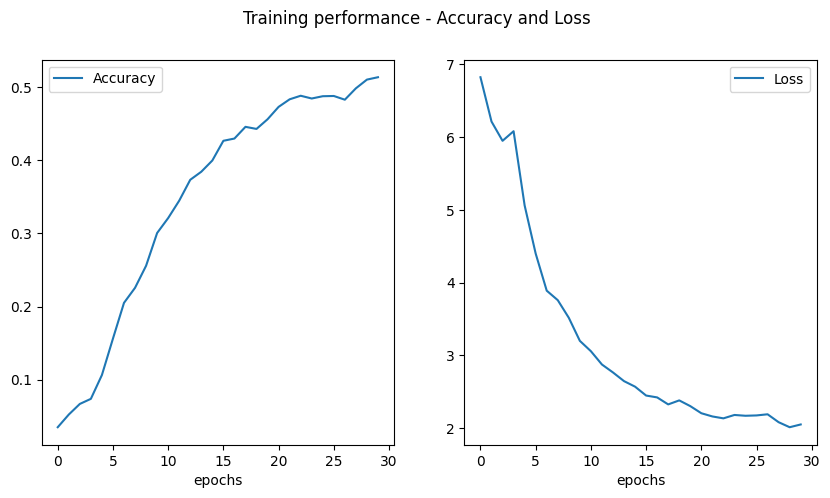

In [31]:
# Get training and validation accuracies
acc = history.history['accuracy']
loss = history.history['loss']

# Get number of epochs
epochs = range(len(acc))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Training performance - Accuracy and Loss')

for i, (data, label) in enumerate(zip([acc,loss], ["Accuracy", "Loss"])):
    ax[i].plot(epochs, data, label=label)
    ax[i].legend()
    ax[i].set_xlabel('epochs')

In [33]:
seed_text = "Help me Obi Wan Kenobi, you're my only hope"
next_words = 100
  
for _ in range(next_words):
    # Convert the text into sequences
    token_list = vectorize_layer(seed_text)
    # Pad the sequences
    token_list = tf.keras.utils.pad_sequences([token_list], maxlen=max_sequence_length-1, padding='pre')
    # Get the probabilities of predicting a word
    predicted = model.predict([token_list], verbose=0)
    # Choose the next word based on the maximum probability
    predicted = np.argmax(predicted, axis=-1).item()
    # Get the actual word from the word index
    output_word = vectorize_layer.get_vocabulary()[predicted]
    # Append to the current text
    seed_text += " " + output_word

print(seed_text)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_5
Received: inputs=('Tensor(shape=(1, 10))',)
  warnings.warn(msg)


Help me Obi Wan Kenobi, you're my only hope write good smell doth thee thee another gay mourners truth it thee thee thee thee those thee thee thee thee hate thee thee thee thine thee array thee thee thee thee resort thee thee thee thee thee thee thee thee thee thee resort thee thee thee thee thee thee thee thee thee thee resort thee thee thee thee thee thee thee thee thee thee resort thee thee thee thee thee thee thee thee thee thee resort thee thee thee thee thee thee thee thee thee thee resort thee thee thee thee thee thee thee thee thee thee resort thee thee
